In [1]:
import pandas as pd

def generate_janam_patri(user_data, years=[1, 3, 10]):
    income_growth = 0.08
    expense_growth = 0.06
    investment_return = 0.10
    emergency_buffer = 3

    age = user_data["Age"]
    income = user_data["Gross monthly income"]
    expenses = user_data["Total Expenses"]
    savings = user_data["Savings"]
    investments = user_data["Investments"]
    emergency_fund = user_data["Emergency Fund"]

    data = []
    for year in range(1, max(years) + 1):
        income *= (1 + income_growth)
        expenses *= (1 + expense_growth)
        yearly_savings = income - expenses

        event = ""
        if yearly_savings < 0:
            event = "⚠️ Fund Shortage"
            yearly_savings = 0

        savings += yearly_savings
        investments *= (1 + investment_return)
        net_worth = savings + investments + emergency_fund

        if emergency_fund < (expenses * emergency_buffer):
            event += " | ❗ Emergency Fund Risk"

        if year in years:
            data.append({
                "Year": f"{year} year(s)",
                "Projected Income (₹)": round(income),
                "Projected Expenses (₹)": round(expenses),
                "Savings (₹)": round(savings),
                "Investments (₹)": round(investments),
                "Net Worth (₹)": round(net_worth),
                "Event/Advice": event or "✅ Stable"
            })

    return pd.DataFrame(data)


In [2]:
user = {
    "Age": 28,
    "Gross monthly income": 50000,
    "Total Expenses": 30000,
    "Savings": 100000,
    "Investments": 80000,
    "Emergency Fund": 20000
}

df = generate_janam_patri(user)
print(df)


         Year  Projected Income (₹)  Projected Expenses (₹)  Savings (₹)  \
0   1 year(s)                 54000                   31800       122200   
1   3 year(s)                 62986                   35730       174067   
2  10 year(s)                107946                   53725       463125   

   Investments (₹)  Net Worth (₹)              Event/Advice  
0            88000         230200   | ❗ Emergency Fund Risk  
1           106480         300547   | ❗ Emergency Fund Risk  
2           207499         690624   | ❗ Emergency Fund Risk  


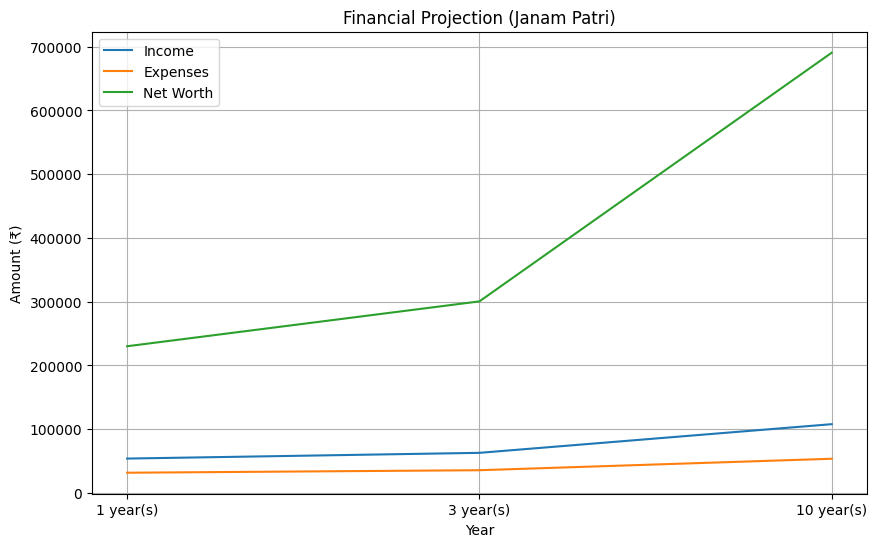

In [3]:
import matplotlib.pyplot as plt

def plot_projection(df):
    plt.figure(figsize=(10, 6))
    plt.plot(df["Year"], df["Projected Income (₹)"], label="Income")
    plt.plot(df["Year"], df["Projected Expenses (₹)"], label="Expenses")
    plt.plot(df["Year"], df["Net Worth (₹)"], label="Net Worth")
    plt.title("Financial Projection (Janam Patri)")
    plt.xlabel("Year")
    plt.ylabel("Amount (₹)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_projection(df)
